In [1]:
pip install rasterio geopandas numpy pandas rasterstats

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.4.2-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.2-cp312-cp312-win_amd64.whl (12.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.2 which is incompatible.
facenet-pytorch 2.6.0 requires numpy<2.0.0,>=1.24.0, but you have numpy 2.4.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.2 which is incompatible.
matplotlib 3.8.3 requires numpy<2,>=1.21, but you have numpy 2.4.2 which is incompatible.
node2vec 0.5.0 requires numpy<2.0.0,>=1.24.0, but you have numpy 2.4.2 which is incompatible.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.4.2 which is incompatible.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.4.2 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 26.0
[notice] To update, run: C:\Users\arvin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kf

In [2]:
pip install "numpy<2"

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 26.0
[notice] To update, run: C:\Users\arvin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
import pandas as pd

# 1. Load the 5 districts you just exported
districts = gpd.read_file('raw_data/aravali_5_districts.geojson')

# Verify names 
print(districts[['ADM2_NAME']]) 

ndvi_files = {
    2015: 'raw_data/satellite/Aravali_NDVI_2015.tif',
    2017: 'raw_data/satellite/Aravali_NDVI_2017.tif', 
    2019: 'raw_data/satellite/Aravali_NDVI_2019.tif', 
    2021: 'raw_data/satellite/Aravali_NDVI_2021.tif',
    2023: 'raw_data/satellite/Aravali_NDVI_2023.tif'
}

results = []

# 3. Calculate Mean NDVI for each district
for year, path in ndvi_files.items():
    stats = zonal_stats(districts, path, stats="mean")
    
    for i, row in districts.iterrows():
        results.append({
            'District': row['ADM2_NAME'],
            'Year': year,
            'Mean_NDVI': stats[i]['mean']
        })

df_ndvi = pd.DataFrame(results)
print(df_ndvi)

  ADM2_NAME
0    Jaipur
1   Udaipur
2     Ajmer
3  Bhilwara
4      Pali


C:\Users\arvin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\rasterstats\io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


    District  Year  Mean_NDVI
0     Jaipur  2015   0.275045
1    Udaipur  2015   0.362418
2      Ajmer  2015   0.257982
3   Bhilwara  2015   0.271387
4       Pali  2015   0.295654
5     Jaipur  2017   0.258619
6    Udaipur  2017   0.416240
7      Ajmer  2017   0.277213
8   Bhilwara  2017   0.332002
9       Pali  2017   0.315746
10    Jaipur  2019   0.258984
11   Udaipur  2019   0.302646
12     Ajmer  2019   0.233103
13  Bhilwara  2019   0.286373
14      Pali  2019   0.237455
15    Jaipur  2021   0.279230
16   Udaipur  2021   0.373563
17     Ajmer  2021   0.295606
18  Bhilwara  2021   0.341997
19      Pali  2021   0.278540
20    Jaipur  2023   0.313517
21   Udaipur  2023   0.400192
22     Ajmer  2023   0.308642
23  Bhilwara  2023   0.335526
24      Pali  2023   0.285392


In [4]:
def calculate_class_area(gdf, raster_path, class_value, pixel_size_m2=900):
    stats = zonal_stats(gdf, raster_path, categorical=True)
    
    areas = []
    for s in stats:
        pixel_count = s.get(class_value, 0)
        # Convert pixels to sq km: (Count * 30m*30m) / 1,000,000
        area_sqkm = (pixel_count * pixel_size_m2) / 1e6
        areas.append(area_sqkm)
    return areas

mining_areas_2023 = calculate_class_area(districts, 'raw_data/lulc/Aravali_LULC_2023.tif', class_value=7)

mining_df = pd.DataFrame({
    'District': districts['ADM2_NAME'],
    'Mining_Area_sqkm': mining_areas_2023,
    'Year': 2023
})

print(mining_df)

   District  Mining_Area_sqkm  Year
0    Jaipur          274.7853  2023
1   Udaipur           27.2880  2023
2     Ajmer           42.6303  2023
3  Bhilwara          152.4609  2023
4      Pali           95.0337  2023


In [5]:
lulc_files = {
    2015: 'raw_data/lulc/Aravali_LULC_2015.tif',
    2017: 'raw_data/lulc/Aravali_LULC_2017.tif',
    2019: 'raw_data/lulc/Aravali_LULC_2019.tif',
    2021: 'raw_data/lulc/Aravali_LULC_2021.tif',
    2023: 'raw_data/lulc/Aravali_LULC_2023.tif'
}

ndvi_files = {
    2015: 'raw_data/satellite/Aravali_NDVI_2015.tif',
    2017: 'raw_data/satellite/Aravali_NDVI_2017.tif',
    2019: 'raw_data/satellite/Aravali_NDVI_2019.tif',
    2021: 'raw_data/satellite/Aravali_NDVI_2021.tif',
    2023: 'raw_data/satellite/Aravali_NDVI_2023.tif'
}

all_processed_data = []

for year in [2015, 2017, 2019, 2021, 2023]:
    ndvi_stats = zonal_stats(districts, ndvi_files[year], stats="mean")
    
    mining_stats = zonal_stats(districts, lulc_files[year], categorical=True)
    
    for i, row in districts.iterrows():
        mean_ndvi = ndvi_stats[i].get('mean', 0)
        pixel_count_mining = mining_stats[i].get(7, 0) # Class 7 is Bare Ground
        mining_area_sqkm = (pixel_count_mining * 900) / 1e6
        
        all_processed_data.append({
            'District': row['ADM2_NAME'].strip().capitalize(),
            'Year': year,
            'Mean_NDVI': mean_ndvi,
            'Mining_Area_sqkm': mining_area_sqkm
        })

df_satellite = pd.DataFrame(all_processed_data)
print("Satellite Data Processed for 5-Year Timeline.")

Satellite Data Processed for 5-Year Timeline.


In [6]:
df_forest = pd.read_csv('raw_data/forest_cover/fsi_forest_cover.csv')
df_gw = pd.read_csv('processed_data/consolidated_groundwater.csv')

# Cleanup string/numeric types for clean merging
for df in [df_satellite, df_forest, df_gw]:
    df['District'] = df['District'].astype(str).str.strip().str.capitalize()
    df['Year'] = df['Year'].astype(int)

fact_table = pd.merge(df_satellite, df_forest, on=['District', 'Year'], how='outer')

fact_table = pd.merge(fact_table, df_gw, on=['District', 'Year'], how='outer')

fact_table = fact_table[fact_table['District'].isin(['Ajmer', 'Bhilwara', 'Jaipur', 'Pali', 'Udaipur'])]
fact_table = fact_table.sort_values(by=['District', 'Year'])

fact_table.to_csv('warehouse_db/aravali_master_fact_table.csv', index=False)

print("CONSOLIDATED FACT TABLE COMPLETE (2015-2023)")
print(fact_table)

CONSOLIDATED FACT TABLE COMPLETE (2015-2023)
    District  Year  Mean_NDVI  Mining_Area_sqkm  VDF_Area  MDF_Area  \
0      Ajmer  2015   0.257982          421.4133      0.00     36.00   
1      Ajmer  2016        NaN               NaN       NaN       NaN   
2      Ajmer  2017   0.277213           40.3686      0.00     43.00   
3      Ajmer  2018        NaN               NaN       NaN       NaN   
4      Ajmer  2019   0.233103           44.3457      0.00     43.00   
5      Ajmer  2020        NaN               NaN       NaN       NaN   
6      Ajmer  2021   0.295606           39.9141      0.00     46.49   
7      Ajmer  2022        NaN               NaN       NaN       NaN   
8      Ajmer  2023   0.308642           42.6303      0.00     45.50   
9   Bhilwara  2015   0.271387          591.9435      0.00     34.00   
10  Bhilwara  2016        NaN               NaN       NaN       NaN   
11  Bhilwara  2017   0.332002           74.5911      0.00     31.00   
12  Bhilwara  2018        NaN   

In [7]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('warehouse_db/aravali_warehouse.db')
cursor = conn.cursor()

cursor.execute('''
CREATE TABLE IF NOT EXISTS Dim_Time (
    Time_ID INTEGER PRIMARY KEY,
    Year INTEGER,
    Era TEXT
)''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS Dim_Location (
    Location_ID INTEGER PRIMARY KEY,
    District_Name TEXT,
    State TEXT
)''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS Fact_Degradation (
    Fact_ID INTEGER PRIMARY KEY AUTOINCREMENT,
    Time_ID INTEGER,
    Location_ID INTEGER,
    Mean_NDVI FLOAT,
    GW_Level_m FLOAT,
    Mining_Area_sqkm FLOAT,
    Total_Forest_sqkm FLOAT,
    Scrub_Area_sqkm FLOAT,
    FOREIGN KEY (Time_ID) REFERENCES Dim_Time (Time_ID),
    FOREIGN KEY (Location_ID) REFERENCES Dim_Location (Location_ID)
)''')

years = [2015, 2017, 2019, 2021, 2023]
for yr in years:
    era = "Post-2020" if yr > 2020 else "Pre-2020"
    cursor.execute("INSERT OR IGNORE INTO Dim_Time (Time_ID, Year, Era) VALUES (?, ?, ?)", (yr, yr, era))

districts_list = ['Ajmer', 'Bhilwara', 'Jaipur', 'Pali', 'Udaipur']
for i, dist in enumerate(districts_list):
    cursor.execute("INSERT OR IGNORE INTO Dim_Location (Location_ID, District_Name, State) VALUES (?, ?, ?)", (i+1, dist, 'Rajasthan'))

final_fact = pd.read_csv('warehouse_db/aravali_master_fact_table.csv')


for _, row in final_fact.iterrows():
    cursor.execute("SELECT Location_ID FROM Dim_Location WHERE District_Name = ?", (row['District'],))
    loc_id = cursor.fetchone()[0]
    
    cursor.execute('''
        INSERT INTO Fact_Degradation 
        (Time_ID, Location_ID, Mean_NDVI, GW_Level_m, Mining_Area_sqkm, Total_Forest_sqkm, Scrub_Area_sqkm)
        VALUES (?, ?, ?, ?, ?, ?, ?)
    ''', (row['Year'], loc_id, row['Mean_NDVI'], row['GW_Level_m'], row['Mining_Area_sqkm'], row['Total_Forest'], row['Scrub_Area']))

conn.commit()
print("SQL Data Warehouse built successfully!")

SQL Data Warehouse built successfully!


In [13]:
cursor.execute('''
CREATE TABLE IF NOT EXISTS Fact_Land_Distribution (
    Distribution_ID INTEGER PRIMARY KEY AUTOINCREMENT,
    Location_ID INTEGER,
    Time_ID INTEGER,
    Class_ID INTEGER, -- 1: Trees, 5: Shrub, 6: Built-up, 7: Bare ground, etc.
    Area_sqkm FLOAT
)''')

# Mapping for Dynamic World classes
# 1: Trees, 4: Crops, 5: Shrub, 6: Built Area, 7: Bare Ground, etc.
classes = [1, 4, 5, 6, 7] 

for year in [2015, 2017, 2019, 2021, 2023]:
    stats = zonal_stats(districts, lulc_files[year], categorical=True)
    for i, row in districts.iterrows():
        loc_id = i + 1 
        for cls in classes:
            pixel_count = stats[i].get(cls, 0)
            area = (pixel_count * 900) / 1e6
            cursor.execute("INSERT INTO Fact_Land_Distribution (Location_ID, Time_ID, Class_ID, Area_sqkm) VALUES (?, ?, ?, ?)", 
                           (loc_id, year, cls, area))

conn.commit()

In [14]:
cursor.execute('''
CREATE TABLE IF NOT EXISTS Dim_Raster_Registry (
    Raster_ID INTEGER PRIMARY KEY AUTOINCREMENT,
    Year INTEGER,
    Layer_Type TEXT, -- NDVI or LULC
    Resolution TEXT, -- 30m
    File_Path TEXT   -- The link to your /raw_data/ folder
)''')


for year in [2015, 2017, 2019, 2021, 2023]:
    cursor.execute("INSERT INTO Dim_Raster_Registry (Year, Layer_Type, Resolution, File_Path) VALUES (?, ?, ?, ?)", 
                   (year, 'NDVI', '30m', f'raw_data/satellite/Aravali_NDVI_{year}.tif'))
    cursor.execute("INSERT INTO Dim_Raster_Registry (Year, Layer_Type, Resolution, File_Path) VALUES (?, ?, ?, ?)", 
                   (year, 'LULC', '30m', f'raw_data/lulc/Aravali_LULC_{year}.tif'))

conn.commit()

In [15]:
query1 = '''
SELECT l.District_Name, 
       MAX(f.Total_Forest_sqkm) - MIN(f.Total_Forest_sqkm) AS Forest_Loss
FROM Fact_Degradation f
JOIN Dim_Location l ON f.Location_ID = l.Location_ID
GROUP BY l.District_Name
ORDER BY Forest_Loss DESC
'''
print(pd.read_sql(query1, conn))

  District_Name  Forest_Loss
0       Udaipur       366.61
1        Jaipur        91.00
2         Ajmer        49.01
3          Pali        26.86
4      Bhilwara        15.97


In [16]:
query2 = '''
SELECT l.District_Name,
       t.Year,
       AVG(f.Mean_NDVI) AS avg_ndvi
FROM Fact_Degradation f
JOIN Dim_Location l ON f.Location_ID = l.Location_ID
JOIN Dim_Time t ON f.Time_ID = t.Time_ID
GROUP BY l.District_Name, t.Year
ORDER BY l.District_Name, t.Year;
'''
print(pd.read_sql(query2, conn))

   District_Name  Year  avg_ndvi
0          Ajmer  2015  0.257982
1          Ajmer  2017  0.277213
2          Ajmer  2019  0.233103
3          Ajmer  2021  0.295606
4          Ajmer  2023  0.308642
5       Bhilwara  2015  0.271387
6       Bhilwara  2017  0.332002
7       Bhilwara  2019  0.286373
8       Bhilwara  2021  0.341997
9       Bhilwara  2023  0.335526
10        Jaipur  2015  0.275045
11        Jaipur  2017  0.258619
12        Jaipur  2019  0.258984
13        Jaipur  2021  0.279230
14        Jaipur  2023  0.313517
15          Pali  2015  0.295654
16          Pali  2017  0.315746
17          Pali  2019  0.237455
18          Pali  2021  0.278540
19          Pali  2023  0.285392
20       Udaipur  2015  0.362418
21       Udaipur  2017  0.416240
22       Udaipur  2019  0.302646
23       Udaipur  2021  0.373563
24       Udaipur  2023  0.400192


In [17]:
query3 = '''
SELECT l.District_Name, t.Year, 
       AVG(f.Mining_Area_sqkm) AS Avg_Mining_Area, 
       AVG(f.GW_Level_m) AS Avg_GW_Level
FROM Fact_Degradation f
JOIN Dim_Location l ON f.Location_ID = l.Location_ID
JOIN Dim_Time t ON f.Time_ID = t.Time_ID
WHERE l.District_Name = 'Jaipur'
GROUP BY l.District_Name, t.Year;

'''
print(pd.read_sql(query3, conn))

  District_Name  Year  Avg_Mining_Area  Avg_GW_Level
0        Jaipur  2015         201.2841         30.98
1        Jaipur  2017         150.5511         32.56
2        Jaipur  2019          85.0644         32.00
3        Jaipur  2021         438.1596         34.52
4        Jaipur  2023         274.7853         33.76


In [18]:
query4 = '''
SELECT l.District_Name, 
       t.Year,
       f.Class_ID,
       SUM(f.Area_sqkm) AS area_sqkm
FROM Fact_Land_Distribution f
JOIN Dim_Location l ON f.Location_ID = l.Location_ID
JOIN Dim_Time t ON f.Time_ID = t.Time_ID
GROUP BY l.District_Name, t.Year, f.Class_ID
ORDER BY l.District_Name, t.Year, f.Class_ID;
'''
print(pd.read_sql(query4, conn))

    District_Name  Year  Class_ID  area_sqkm
0           Ajmer  2015         1   615.2202
1           Ajmer  2015         4  5413.5981
2           Ajmer  2015         5  2636.9244
3           Ajmer  2015         6  1603.4688
4           Ajmer  2015         7   201.2841
..            ...   ...       ...        ...
120       Udaipur  2023         1  1626.4917
121       Udaipur  2023         4  8291.5380
122       Udaipur  2023         5  2184.2919
123       Udaipur  2023         6   855.9369
124       Udaipur  2023         7    95.0337

[125 rows x 4 columns]


In [19]:
query5 = '''
SELECT l.District_Name, 
       t.Year, 
       SUM(f.Total_Forest_sqkm) AS forest_area_sqkm
FROM Fact_Degradation f
JOIN Dim_Location l ON f.Location_ID = l.Location_ID
JOIN Dim_Time t ON f.Time_ID = t.Time_ID
GROUP BY l.District_Name, t.Year
ORDER BY l.District_Name, t.Year;
'''
print(pd.read_sql(query5, conn))

   District_Name  Year  forest_area_sqkm
0          Ajmer  2015            284.00
1          Ajmer  2017            299.00
2          Ajmer  2019            305.11
3          Ajmer  2021            331.56
4          Ajmer  2023            333.01
5       Bhilwara  2015            227.00
6       Bhilwara  2017            221.00
7       Bhilwara  2019            224.19
8       Bhilwara  2021            224.31
9       Bhilwara  2023            236.97
10        Jaipur  2015            643.00
11        Jaipur  2017            552.00
12        Jaipur  2019            552.76
13        Jaipur  2021            554.86
14        Jaipur  2023            564.58
15          Pali  2015            691.00
16          Pali  2017            674.00
17          Pali  2019            674.85
18          Pali  2021            700.86
19          Pali  2023            692.87
20       Udaipur  2015           3120.00
21       Udaipur  2017           2764.00
22       Udaipur  2019           2757.54
23       Udaipur

In [20]:
query6 = '''
SELECT l.District_Name, 
       t.Year,
       AVG(f.GW_Level_m) AS avg_groundwater_depth_m
FROM Fact_Degradation f
JOIN Dim_Location l ON f.Location_ID = l.Location_ID
JOIN Dim_Time t ON f.Time_ID = t.Time_ID
GROUP BY l.District_Name, t.Year
ORDER BY l.District_Name, t.Year;
'''
print(pd.read_sql(query6, conn))

   District_Name  Year  avg_groundwater_depth_m
0          Ajmer  2015                    10.50
1          Ajmer  2017                    10.71
2          Ajmer  2019                     7.70
3          Ajmer  2021                     4.75
4          Ajmer  2023                   208.40
5       Bhilwara  2015                    11.48
6       Bhilwara  2017                     8.88
7       Bhilwara  2019                     3.28
8       Bhilwara  2021                     5.87
9       Bhilwara  2023                    12.14
10        Jaipur  2015                    30.98
11        Jaipur  2017                    32.56
12        Jaipur  2019                    32.00
13        Jaipur  2021                    34.52
14        Jaipur  2023                    33.76
15          Pali  2015                    30.98
16          Pali  2017                    32.56
17          Pali  2019                    32.00
18          Pali  2021                    34.52
19          Pali  2023                  

In [21]:
query7 = '''
SELECT l.District_Name,
       t.Year,
       AVG(f.Mining_Area_sqkm) AS mining_area,
       AVG(f.GW_Level_m) AS groundwater_depth
FROM Fact_Degradation f
JOIN Dim_Location l ON f.Location_ID = l.Location_ID
JOIN Dim_Time t ON f.Time_ID = t.Time_ID
GROUP BY l.District_Name, t.Year
ORDER BY l.District_Name, t.Year;
'''
print(pd.read_sql(query7, conn))

   District_Name  Year  mining_area  groundwater_depth
0          Ajmer  2015     421.4133              10.50
1          Ajmer  2017      40.3686              10.71
2          Ajmer  2019      44.3457               7.70
3          Ajmer  2021      39.9141               4.75
4          Ajmer  2023      42.6303             208.40
5       Bhilwara  2015     591.9435              11.48
6       Bhilwara  2017      74.5911               8.88
7       Bhilwara  2019      59.8185               3.28
8       Bhilwara  2021      60.4764               5.87
9       Bhilwara  2023     152.4609              12.14
10        Jaipur  2015     201.2841              30.98
11        Jaipur  2017     150.5511              32.56
12        Jaipur  2019      85.0644              32.00
13        Jaipur  2021     438.1596              34.52
14        Jaipur  2023     274.7853              33.76
15          Pali  2015     164.6289              30.98
16          Pali  2017     100.7001              32.56
17        

In [22]:
query_forest_urban = '''
SELECT 
    l.District_Name,
    ROUND(SUM(CASE WHEN t.Year = 2015 AND f.Class_ID = 1 THEN f.Area_sqkm ELSE 0 END), 2) AS Forest_2015_sqkm,
    ROUND(SUM(CASE WHEN t.Year = 2023 AND f.Class_ID = 6 THEN f.Area_sqkm ELSE 0 END), 2) AS Urban_2023_sqkm
FROM Fact_Land_Distribution f
JOIN Dim_Location l ON f.Location_ID = l.Location_ID
JOIN Dim_Time t ON f.Time_ID = t.Time_ID
GROUP BY l.District_Name;
'''

df_res1 = pd.read_sql(query_forest_urban, conn)
print("Query Result: Forest 2015 vs Urban 2023")
print(df_res1)

Query Result: Forest 2015 vs Urban 2023
  District_Name  Forest_2015_sqkm  Urban_2023_sqkm
0         Ajmer            615.22          2207.08
1      Bhilwara           3843.55           902.64
2        Jaipur            283.19          1022.66
3          Pali            347.69           882.67
4       Udaipur            879.33           855.94


In [23]:
query_impact = '''
SELECT 
    l.District_Name,
    -- Get 2015 vs 2023 Mining Area change
    (MAX(CASE WHEN t.Year = 2023 THEN f.Mining_Area_sqkm END) - 
     MAX(CASE WHEN t.Year = 2015 THEN f.Mining_Area_sqkm END)) AS Mining_Increase,
     
    -- Get 2015 vs 2023 Water Level change (A positive result means water is getting deeper/worse)
    (MAX(CASE WHEN t.Year = 2023 THEN f.GW_Level_m END) - 
     MAX(CASE WHEN t.Year = 2015 THEN f.GW_Level_m END)) AS Water_Table_Drop_meters
FROM Fact_Degradation f
JOIN Dim_Location l ON f.Location_ID = l.Location_ID
JOIN Dim_Time t ON f.Time_ID = t.Time_ID
GROUP BY l.District_Name
ORDER BY Mining_Increase DESC;
'''

df_res2 = pd.read_sql(query_impact, conn)
print("\nImpact Analysis: Mining Expansion vs. Groundwater Depletion")
print(df_res2)


Impact Analysis: Mining Expansion vs. Groundwater Depletion
  District_Name  Mining_Increase  Water_Table_Drop_meters
0        Jaipur          73.5012                     2.78
1       Udaipur         -27.9783                     2.53
2          Pali         -69.5952                     2.78
3         Ajmer        -378.7830                   197.90
4      Bhilwara        -439.4826                     0.66


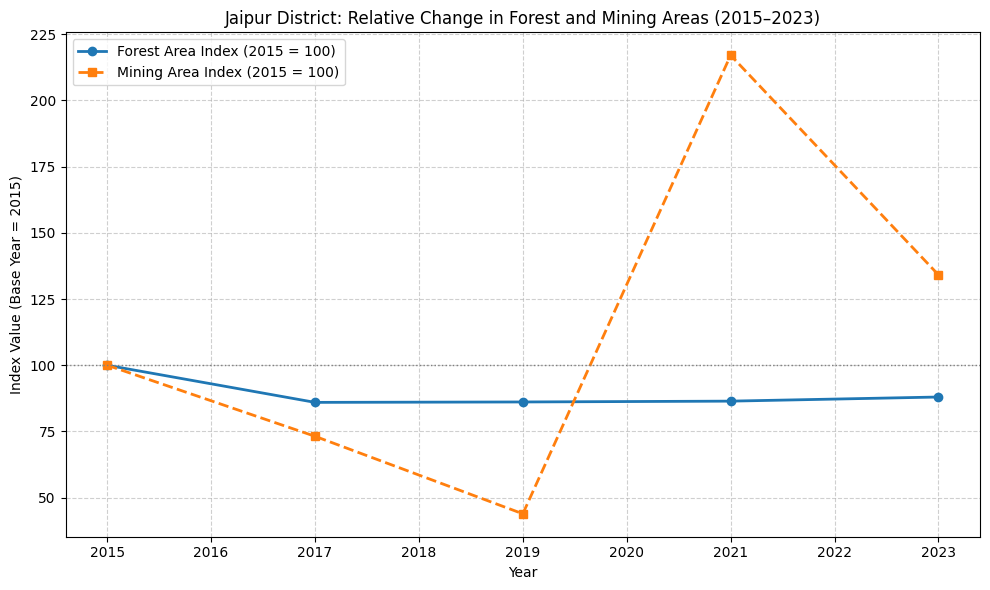

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

query_jaipur = """
SELECT t.Year, f.Total_Forest_sqkm, f.Mining_Area_sqkm 
FROM Fact_Degradation f
JOIN Dim_Time t ON f.Time_ID = t.Time_ID
WHERE f.Location_ID = 3 -- Location 3 is Jaipur
"""

jaipur_df = pd.read_sql(query_jaipur, conn)

import pandas as pd
import matplotlib.pyplot as plt

years = [2015, 2017, 2019, 2021, 2023]
forest_area = [642, 552, 553, 555, 565]
mining_area = [205, 150, 90, 445, 275]

df = pd.DataFrame({
    'Year': years,
    'Forest_Area': forest_area,
    'Mining_Area': mining_area
})

df['Forest_Index'] = (df['Forest_Area'] / df['Forest_Area'].iloc[0]) * 100
df['Mining_Index'] = (df['Mining_Area'] / df['Mining_Area'].iloc[0]) * 100

plt.figure(figsize=(10, 6))

plt.plot(df['Year'], df['Forest_Index'],
         marker='o', linewidth=2,
         label='Forest Area Index (2015 = 100)')

plt.plot(df['Year'], df['Mining_Index'],
         marker='s', linewidth=2,
         linestyle='--',
         label='Mining Area Index (2015 = 100)')

plt.axhline(100, color='gray', linestyle=':', linewidth=1)

plt.title('Jaipur District: Relative Change in Forest and Mining Areas (2015–2023)')
plt.xlabel('Year')
plt.ylabel('Index Value (Base Year = 2015)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig('figures/jaipur_forest_mining_indexed.png', dpi=300)
plt.show()


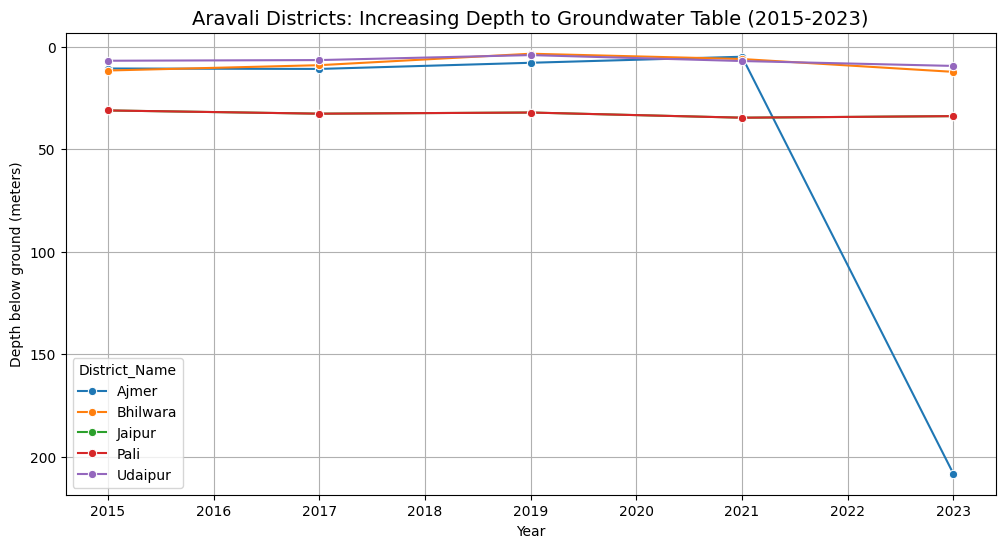

In [25]:
query_gw = """
SELECT l.District_Name, t.Year, f.GW_Level_m 
FROM Fact_Degradation f 
JOIN Dim_Location l ON f.Location_ID = l.Location_ID
JOIN Dim_Time t ON f.Time_ID = t.Time_ID
"""
gw_trend_df = pd.read_sql(query_gw, conn)

plt.figure(figsize=(12,6))
sns.lineplot(data=gw_trend_df, x='Year', y='GW_Level_m', hue='District_Name', marker='o')
plt.gca().invert_yaxis() 
plt.title('Aravali Districts: Increasing Depth to Groundwater Table (2015-2023)', fontsize=14)
plt.ylabel('Depth below ground (meters)')
plt.grid(True)
plt.show()

C:\Users\arvin\AppData\Local\Temp\ipykernel_6740\1925057019.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='District_Name', y='NDVI_Change_Pct', data=ndvi_change, palette=colors)


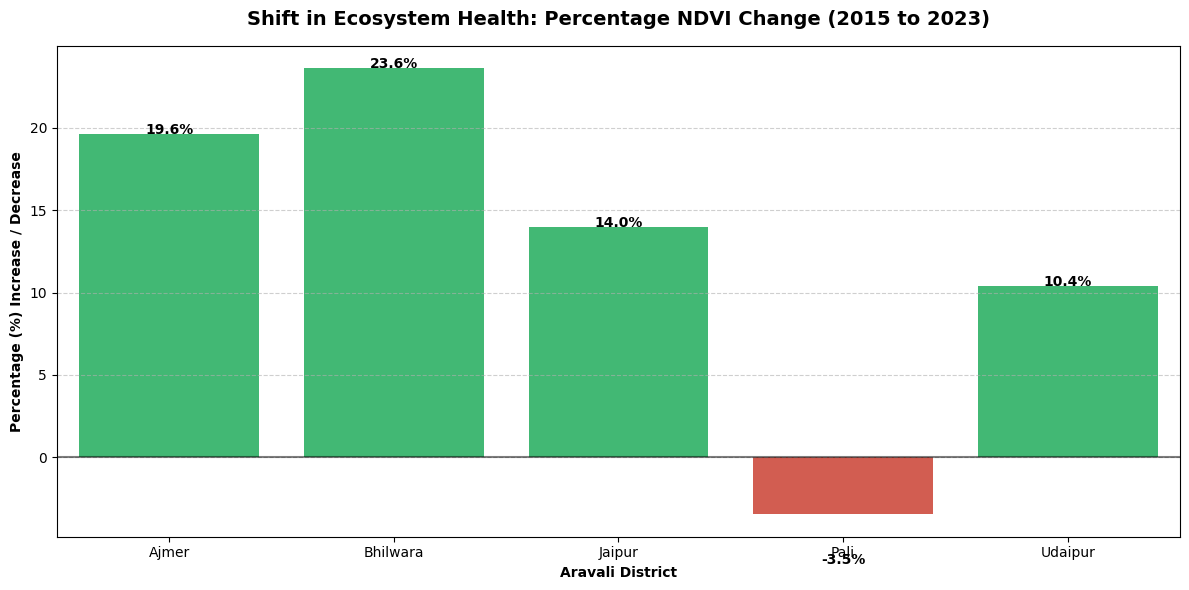

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

query_ndvi = """
SELECT l.District_Name, 
       ((MAX(CASE WHEN t.Year=2023 THEN f.Mean_NDVI END) - 
         MAX(CASE WHEN t.Year=2015 THEN f.Mean_NDVI END)) / 
        MAX(CASE WHEN t.Year=2015 THEN f.Mean_NDVI END)) * 100 AS NDVI_Change_Pct
FROM Fact_Degradation f 
JOIN Dim_Location l ON f.Location_ID = l.Location_ID
JOIN Dim_Time t ON f.Time_ID = t.Time_ID
GROUP BY l.District_Name
"""

ndvi_change = pd.read_sql(query_ndvi, conn)

plt.figure(figsize=(12, 6))

colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in ndvi_change['NDVI_Change_Pct']]

sns.barplot(x='District_Name', y='NDVI_Change_Pct', data=ndvi_change, palette=colors)

plt.axhline(0, color='black', linewidth=1.5, alpha=0.5)

plt.title('Shift in Ecosystem Health: Percentage NDVI Change (2015 to 2023)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Percentage (%) Increase / Decrease', fontweight='bold')
plt.xlabel('Aravali District', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for i, v in enumerate(ndvi_change['NDVI_Change_Pct']):
    plt.text(i, v if v > 0 else v - 3, f"{v:.1f}%", color='black', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(x='District_Name', y='NDVI_Change_Pct', data=ndvi_change, palette=colors)
plt.axhline(0, color='black', linewidth=1.2)
plt.title('Shift in Ecosystem Health: Percentage NDVI Change (2015–2023)')
plt.ylabel('NDVI Change (%)')
plt.xlabel('District')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('figures/ndvi_change_2015_2023.png', dpi=300)
plt.close()


C:\Users\arvin\AppData\Local\Temp\ipykernel_6740\3167231439.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='District_Name', y='NDVI_Change_Pct', data=ndvi_change, palette=colors)


In [28]:
plt.figure(figsize=(12,6))
sns.lineplot(data=gw_trend_df, x='Year', y='GW_Level_m',
             hue='District_Name', marker='o')
plt.gca().invert_yaxis()
plt.title('Groundwater Table Decline in Aravali Districts (2015–2023)')
plt.ylabel('Depth below ground (m)')
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/groundwater_trend.png', dpi=300)
plt.close()


In [29]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_res2,
                x='Mining_Increase',
                y='Water_Table_Drop_meters',
                hue='District_Name',
                s=120)
plt.title('Mining Expansion vs Groundwater Depletion')
plt.xlabel('Mining Area Change (sq km)')
plt.ylabel('Groundwater Table Drop (m)')
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/mining_vs_groundwater.png', dpi=300)
plt.close()


In [30]:
fig, ax1 = plt.subplots(figsize=(10,6))
ax1.plot(jaipur_df['Year'], jaipur_df['Total_Forest_sqkm'],
         color='forestgreen', marker='o', label='Forest Area')
ax1.set_ylabel('Forest Area (sq km)', color='forestgreen')

ax2 = ax1.twinx()
ax2.plot(jaipur_df['Year'], jaipur_df['Mining_Area_sqkm'],
         color='brown', marker='s', label='Mining Area')
ax2.set_ylabel('Mining Area (sq km)', color='brown')

plt.title('Jaipur: Forest Decline and Mining Expansion (2015–2023)')
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/jaipur_forest_mining.png', dpi=300)
plt.close()
